[SISTEMA] Bibliotecas importadas com sucesso.
[PROCESSAMENTO] Carregando dataset...
[INFO] Dataset carregado. Linhas: 284807, Colunas: 31
[PROCESSAMENTO] Aplicando SMOTE para balancear os dados de treino...
[INFO] Distribuição original do treino: 
Class
0    199020
1       344
Name: count, dtype: int64
[INFO] Distribuição após SMOTE: 
Class
0    199020
1    199020
Name: count, dtype: int64
[PROCESSAMENTO] Treinando modelo XGBoost...
[PROCESSAMENTO] Avaliando o modelo nos dados de teste...

RELATÓRIO DE CLASSIFICAÇÃO (XGBOOST)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.74      0.80      0.77       148

    accuracy                           1.00     85443
   macro avg       0.87      0.90      0.89     85443
weighted avg       1.00      1.00      1.00     85443

[PROCESSAMENTO] Gerando explicabilidade com SHAP (Aguarde, pode levar alguns segundos)...

[INFO] Gráfico de Importância das Variáveis (SHAP 

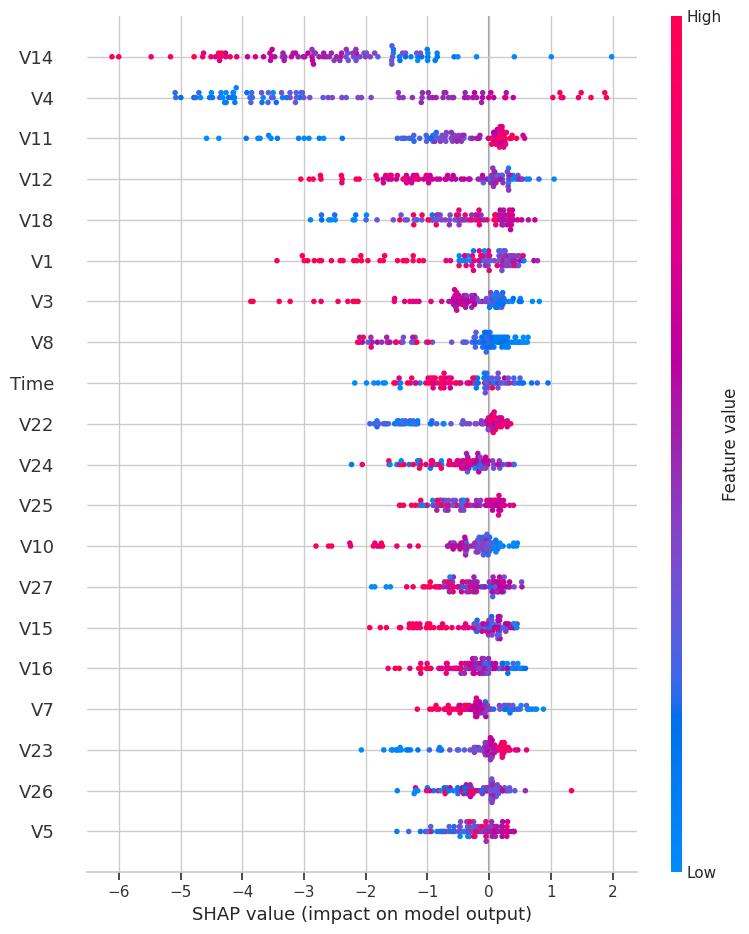

In [1]:
# ==============================================================================
# PROJETO: Detecção de Anomalias em Transações (Fraudes)
# ==============================================================================

# 1. Instalação de pacotes necessários (SHAP para explicabilidade e imbalanced-learn para SMOTE)
!pip install shap imbalanced-learn xgboost -q

# 2. Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

# Configuração visual
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

print("[SISTEMA] Bibliotecas importadas com sucesso.")

# ==============================================================================
# 3. Coleta e Preparação dos Dados
# ==============================================================================
print("[PROCESSAMENTO] Carregando dataset...")
# NOTA: Usando um link público padrão para o dataset de fraudes de cartão de crédito
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

print(f"[INFO] Dataset carregado. Linhas: {df.shape[0]}, Colunas: {df.shape[1]}")

# Separando features (X) e target (y)
# A coluna 'Class' é 1 para fraude e 0 para normal
X = df.drop('Class', axis=1)
y = df['Class']

# Padronização dos dados (StandardScaler)
# Modelos baseados em distância e gradiente performam melhor com dados padronizados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Divisão em Treino e Teste (Estratificado para manter a proporção de fraudes)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# ==============================================================================
# 4. Balanceamento de Dados (SMOTE)
# ==============================================================================
print("[PROCESSAMENTO] Aplicando SMOTE para balancear os dados de treino...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"[INFO] Distribuição original do treino: \n{y_train.value_counts()}")
print(f"[INFO] Distribuição após SMOTE: \n{y_train_smote.value_counts()}")

# ==============================================================================
# 5. Treinamento do Modelo Avançado (XGBoost)
# ==============================================================================
print("[PROCESSAMENTO] Treinando modelo XGBoost...")
# Usamos scale_pos_weight para lidar com o desbalanceamento residual, se houver
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_smote, y_train_smote)

# ==============================================================================
# 6. Avaliação do Modelo
# ==============================================================================
print("[PROCESSAMENTO] Avaliando o modelo nos dados de teste...")
y_pred = xgb_model.predict(X_test)

print("\n" + "="*50)
print("RELATÓRIO DE CLASSIFICAÇÃO (XGBOOST)")
print("="*50)
print(classification_report(y_test, y_pred))

# ==============================================================================
# 7. Explicabilidade do Modelo (SHAP)
# ==============================================================================
print("[PROCESSAMENTO] Gerando explicabilidade com SHAP (Aguarde, pode levar alguns segundos)...")
# Usamos um sample menor do teste para o SHAP calcular mais rápido
X_test_sample = shap.sample(X_test, 100)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)

print("\n[INFO] Gráfico de Importância das Variáveis (SHAP Summary Plot):")
shap.summary_plot(shap_values, X_test_sample, feature_names=X.columns)